[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nikbaya/smartbiomed_practicals_2026/blob/main/session1/run.ipynb)

# Session 1: Introduction to GWAS — Practical

**Timing**: This practical is designed for ~45 minutes.
- Parts 1–3 should take ~30–35 minutes.
- Challenge questions are for fast finishers.

**Dataset**: Simulated GWAS data for ~100,000 variants with realistic block LD across chr1 (1–250 Mb).
- Continuous trait: simulated liability phenotype (h² ≈ 0.035, MAF-dependent spike-and-slab prior).
- Binary trait: derived from the continuous liability via a threshold model (~10% cases).

**Tip**: If you get stuck on any exercise, hints are in the comments. Solutions are in `answers.ipynb`.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy import stats, special
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 80, 'font.size': 11})
print("Libraries loaded.")


/Users/nbaya/miniconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Libraries loaded.


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# SETUP — Run this cell once. No modification needed.
# Loads the pre-generated GWAS dataset (or falls back to a synthetic version).
# ─────────────────────────────────────────────────────────────────────────────
import os, numpy as np, pandas as pd
from scipy import stats, special
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings; warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 80, 'font.size': 11})

# Locate the data directory, downloading from GitHub if needed (e.g. on Colab).
import os, urllib.request
_NEED = ['gwas_data.npz', 'fly_data.csv']
_LFS  = {'gwas_data.npz', 'sumstats_real.npz'}   # tracked with Git LFS (media URL)
def _has_all(d):
    return d and all(os.path.exists(os.path.join(d, f)) for f in _NEED)
DATA_DIR = next((d for d in ('../data', 'data') if _has_all(d)), None)
if DATA_DIR is None:
    DATA_DIR = 'data'; os.makedirs(DATA_DIR, exist_ok=True)
    for _f in _NEED:
        _dest = os.path.join(DATA_DIR, _f)
        if os.path.exists(_dest):
            continue
        _base = ('https://media.githubusercontent.com/media' if _f in _LFS
                 else 'https://raw.githubusercontent.com')
        _url = f'{_base}/nikbaya/smartbiomed_practicals_2026/main/data/{_f}'
        print(f'Downloading {_f} from GitHub ...')
        urllib.request.urlretrieve(_url, _dest)

if os.path.exists(os.path.join(DATA_DIR, 'gwas_data.npz')):
    print("Loading pre-generated GWAS data...")
    d = np.load(os.path.join(DATA_DIR, 'gwas_data.npz'), allow_pickle=True)
    _G    = d['G_raw']                        # int8: 0/1/2, -1=missing (compact storage)
    G_raw = np.where(_G == -1, np.nan, _G.astype(np.float32))  # float32 NaN for missing
    del _G
    pos        = d['pos']                    # variant positions (kbp)
    rsids      = d['rsids']                  # variant RSIDs
    age        = d['age']
    sex        = d['sex']                    # 0=female, 1=male
    y_cont     = d['y_cont']                 # continuous trait (h²≈0.035, few causal variants)
    y_poly     = d['y_poly']                 # polygenic trait  (h²≈0.02, fully polygenic)
    y_bin      = d['y_bin']                  # binary trait     (~10% cases, liability threshold)
    true_betas = d['true_betas']             # true causal effect sizes
    dom_idx_qc = int(d['dom_idx_qc'][0])     # post-QC column index of dominant locus
    rec_idx_qc = int(d['rec_idx_qc'][0])     # post-QC column index of recessive locus
    fly_df     = pd.read_csv(os.path.join(DATA_DIR, 'fly_data.csv'))
    N, M_raw = G_raw.shape
    CHROM = 1
    print(f"Loaded: {N:,} samples × {M_raw:,} variants (chr{CHROM}, pre-QC)")
    print(f"  Continuous trait: standardised liability (h²≈0.035)")
    print(f"  Binary trait: {y_bin.sum():,} cases ({100*y_bin.mean():.1f}%, liability threshold)")
else:
    # ── Fallback: generate a synthetic dataset with block LD ──────────────────────
    # Used when the instructor-provided data files are not present.
    # Results are reproducible (fixed seed) but use simulated rather than real LD.
    np.random.seed(2026)
    N, M_raw = 10_000, 12_000
    CHROM = 1          # all variants on chr1 (simulated)
    POS_START = 1_000  # kbp
    
    # EUR-like MAF distribution: right-skewed, min 5% for block-LD variants
    maf_true = np.random.beta(0.5, 2.0, M_raw) * 0.45 + 0.05
    
    # Block LD: groups of 50 variants share a common ancestor haplotype (r²≈0.64)
    block_size = 50
    G_hap1 = np.zeros((N, M_raw), dtype=np.int8)
    G_hap2 = np.zeros((N, M_raw), dtype=np.int8)
    for b in range((M_raw - 1) // block_size + 1):
        s = b * block_size;  e = min(s + block_size, M_raw);  nb = e - s
        anc = np.random.rand(N) < maf_true[s:e].mean()
        alpha = 0.8
        for hap_arr in [G_hap1, G_hap2]:
            mix  = np.random.rand(N, nb) < alpha
            indp = (np.random.rand(N, nb) < maf_true[None, s:e])
            hap_arr[:, s:e] = np.where(mix, anc[:, None], indp).astype(np.int8)
    
    G_raw = G_hap1 + G_hap2   # diploid (0/1/2), shape (N, M_raw)
    
    # Inject rare variants (MAF 0.1–1%) — fail MAF QC
    rare_cols_fb = np.random.choice(M_raw, 1000, replace=False)
    for _j in rare_cols_fb:
        _af = np.random.uniform(0.001, 0.01)
        G_raw[:, _j] = np.random.binomial(2, _af, N).astype(float)
    
    # Inject other QC failures
    non_rare_fb = np.setdiff1d(np.arange(M_raw), rare_cols_fb)
    hwe_bad = np.random.choice(non_rare_fb, 500, replace=False)
    remaining = np.setdiff1d(non_rare_fb, hwe_bad)
    miss_bad = np.random.choice(remaining, 300, replace=False)
    low_miss_vars = np.random.choice(np.setdiff1d(remaining, miss_bad), 2500, replace=False)
    for j in hwe_bad:
        mask = G_raw[:, j] == 1
        G_raw[mask, j] = np.random.choice([0, 2], mask.sum())
    G_raw_f = G_raw.astype(float)
    for j in miss_bad:
        n_miss = np.random.randint(int(0.06 * N), int(0.20 * N))
        idx = np.random.choice(N, n_miss, replace=False)
        G_raw_f[idx, j] = np.nan
    for j in low_miss_vars:
        n_miss = np.random.randint(int(0.005 * N), int(0.045 * N))
        idx = np.random.choice(N, n_miss, replace=False)
        G_raw_f[idx, j] = np.nan
    G_raw = G_raw_f
    
    pos = (POS_START + np.arange(M_raw) * 2.5).astype(int)  # ~2.5 kb spacing (kbp)
    rsids = np.array([f"rs{100000 + i}" for i in range(M_raw)])
    
    # Covariates (UKB-like): age-at-recruitment distribution (range 37–73, median 58)
    _p_age = [0, .10, .20, .30, .40, .50, .60, .70, .80, .90, 1.0]
    _v_age = [37, 44, 48, 52, 55, 58, 60, 62, 64, 67, 73]
    age = np.interp(np.random.rand(N), _p_age, _v_age)
    sex = np.random.binomial(1, 0.5, N)  # 0=female, 1=male
    
    # Simulate continuous phenotype: spike-and-slab prior (h²≈0.035), few causal variants
    n_causal = 3   # 3 causal variants, low h², realistic QQ plot
    causal_idx = np.sort(np.random.choice(M_raw, n_causal, replace=False))
    true_betas = np.zeros(M_raw)
    # MAF-dependent effect sizes (rare variants get larger effects)
    het_c = 2 * maf_true[causal_idx] * (1 - maf_true[causal_idx])
    sigma_c = (het_c + 1e-8) ** (-0.375); sigma_c /= sigma_c.mean()
    true_betas[causal_idx] = np.random.normal(0, 0.3 * sigma_c)
    
    G_clean = np.where(np.isnan(G_raw), 0, G_raw)
    G_std = (G_clean - np.nanmean(G_raw, 0)) / (np.nanstd(G_raw, 0) + 1e-8)
    genetic_cont = G_std @ true_betas
    genetic_cont = genetic_cont / (genetic_cont.std() + 1e-8) * np.sqrt(0.025)
    y_cont = (genetic_cont
              + 0.15 * (sex - 0.5)
              + 0.10 * (age - 57) / 8
              + np.random.normal(0, np.sqrt(0.965), N))
    y_cont = (y_cont - y_cont.mean()) / y_cont.std()
    
    # Binary phenotype via liability threshold (~10% cases)
    threshold = np.percentile(y_cont, 90)
    y_bin = (y_cont >= threshold).astype(np.int8)
    
    # Fly cross dataset
    np.random.seed(42)
    n_fly = 2000
    x_pos_cM = np.array([0.0, 5.0, 15.0, 30.0, 35.0, 50.0])
    fly_sex = np.array([1]*(n_fly//2) + [0]*(n_fly - n_fly//2))
    male_haps = np.zeros((n_fly//2, 6), dtype=np.int8)
    for i in range(n_fly//2):
        curr = np.random.randint(0, 2)
        male_haps[i, 0] = curr
        for j in range(1, 6):
            curr = (curr + np.random.poisson((x_pos_cM[j] - x_pos_cM[j-1]) / 100)) % 2
            male_haps[i, j] = curr
    x_phenos = np.vstack([male_haps, np.zeros((n_fly - n_fly//2, 6), dtype=np.int8)])
    auto_tr = np.column_stack([np.random.binomial(1, 0.35, n_fly),
                                np.random.binomial(1, 0.48, n_fly)])
    perm = np.random.permutation(n_fly)
    fly_df = pd.DataFrame({
        'sex':          fly_sex[perm],
        'trait_eye':    x_phenos[perm, 0], 'trait_thorax': auto_tr[perm, 0],
        'trait_wing':   x_phenos[perm, 1], 'trait_leg':    x_phenos[perm, 2],
        'trait_notch':  x_phenos[perm, 3], 'trait_vein':   x_phenos[perm, 4],
        'trait_scute':  x_phenos[perm, 5], 'trait_band':   auto_tr[perm, 1],
    })
    # Polygenic trait: fully polygenic, very low h², uncorrelated with y_cont
    G_clean_p = np.where(np.isnan(G_raw), 0, G_raw)
    betas_poly_fb = np.random.normal(0, 1, M_raw) / np.sqrt(M_raw)
    y_poly_g = G_clean_p @ betas_poly_fb
    y_poly_g = y_poly_g / (y_poly_g.std() + 1e-8) * np.sqrt(0.02)
    y_poly = (y_poly_g + np.random.normal(0, np.sqrt(0.98), N))
    y_poly = (y_poly - y_poly.mean()) / y_poly.std()
    
    dom_idx_qc = -1; rec_idx_qc = -1   # non-additive loci not available in fallback
    print("Fallback dataset ready (block-LD simulation, spike-and-slab phenotype)")

N, M_raw = G_raw.shape
print(f"\nReady: N={N:,} samples, M_raw={M_raw:,} variants (pre-QC)")


Loading pre-generated GWAS data...
Loaded: 10,000 samples × 52,500 variants (chr1, pre-QC)
  Continuous trait: standardised liability (h²≈0.035)
  Binary trait: 1,000 cases (10.0%, liability threshold)

Ready: N=10,000 samples, M_raw=52,500 variants (pre-QC)


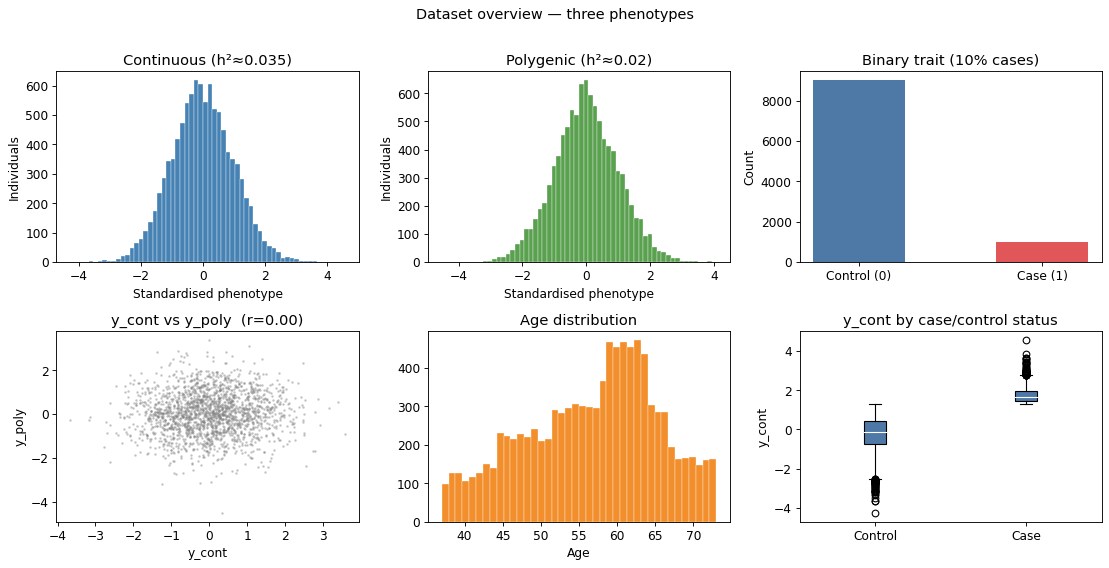

N = 10,000 individuals  |  M_raw = 52,500 variants (pre-QC)  |  Cases: 1,000 (10%)
Pearson r(y_cont, y_poly) = 0.004  — in Session 2 you will test which trait pairs are genetically correlated.


In [3]:
# ── Phenotype and covariate distributions ────────────────────────────────────
# Three traits to characterise:
#   y_cont — continuous (h²≈0.035, few large-effect causal variants)
#   y_poly — continuous (h²≈0.02, fully polygenic — every variant has a tiny effect)
#   y_bin  — binary (~10% cases, derived from y_cont via liability threshold)
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for ax, y, col, lbl in zip(
        [axes[0,0], axes[0,1]],
        [y_cont, y_poly],
        ['steelblue', '#59a14f'],
        ['Continuous (h²≈0.035)', 'Polygenic (h²≈0.02)']):
    ax.hist(y, bins=60, color=col, edgecolor='white', linewidth=0.3)
    ax.set_xlabel('Standardised phenotype'); ax.set_ylabel('Individuals')
    ax.set_title(lbl)

axes[0,2].bar(['Control (0)', 'Case (1)'],
              [(y_bin==0).sum(), (y_bin==1).sum()],
              color=['#4e79a7', '#e15759'], width=0.5)
axes[0,2].set_ylabel('Count')
axes[0,2].set_title(f'Binary trait ({100*y_bin.mean():.0f}% cases)')

axes[1,0].scatter(y_cont[::5], y_poly[::5], s=2, alpha=0.3, color='grey')
axes[1,0].set_xlabel('y_cont'); axes[1,0].set_ylabel('y_poly')
rho_cp = np.corrcoef(y_cont, y_poly)[0,1]
axes[1,0].set_title(f'y_cont vs y_poly  (r={rho_cp:.2f})')

axes[1,1].hist(age, bins=40, color='#f28e2b', edgecolor='white', linewidth=0.3)
axes[1,1].set_xlabel('Age'); axes[1,1].set_title('Age distribution')

axes[1,2].boxplot([y_cont[y_bin==0], y_cont[y_bin==1]], labels=['Control', 'Case'],
                  patch_artist=True,
                  boxprops=dict(facecolor='#4e79a7'), medianprops=dict(color='white'))
axes[1,2].set_ylabel('y_cont'); axes[1,2].set_title('y_cont by case/control status')

plt.suptitle('Dataset overview — three phenotypes', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()
print(f"N = {N:,} individuals  |  M_raw = {M_raw:,} variants (pre-QC)  |  "
      f"Cases: {y_bin.sum():,} ({100*y_bin.mean():.0f}%)")
print(f"Pearson r(y_cont, y_poly) = {rho_cp:.3f}  "
      f"— in Session 2 you will test which trait pairs are genetically correlated.")


## Part 1: GWAS Quality Control

Before running a GWAS, we need to filter out low-quality variants.
Standard filters remove variants with:
- **High missingness** (call rate < 95%, i.e., >5% samples missing a genotype)
- **Low MAF** (minor allele frequency < 1%; rare variants have low power)
- **HWE violation** (excess homozygosity often indicates genotyping error)

In the following exercises, `G_raw` is the raw genotype matrix (N × M_raw).
Genotypes are coded as 0/1/2 (copies of the effect allele); `NaN` = missing.


Variants with missingness > 5%: 300


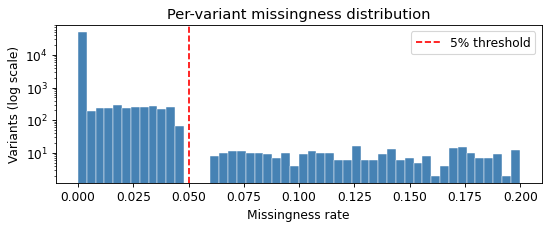

In [4]:
miss_rate = np.isnan(G_raw).mean(axis=0)

print(f"Variants with missingness > 5%: {(miss_rate > 0.05).sum():,}")

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(miss_rate, bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
ax.axvline(0.05, color='red', linestyle='--', label='5% threshold')
ax.set_xlabel('Missingness rate'); ax.set_ylabel('Variants (log scale)')
ax.set_yscale('log'); ax.set_title('Per-variant missingness distribution'); ax.legend()
plt.tight_layout(); plt.show()


Variants with MAF < 1%:  2,904
Variants with MAF < 5%:  3,000


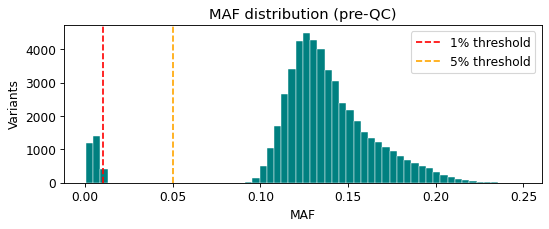

In [5]:
alt_freq = np.nanmean(G_raw, axis=0) / 2
maf      = np.minimum(alt_freq, 1 - alt_freq)

print(f"Variants with MAF < 1%:  {(maf < 0.01).sum():,}")
print(f"Variants with MAF < 5%:  {(maf < 0.05).sum():,}")

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(maf, bins=60, color='teal', edgecolor='white', linewidth=0.4)
ax.axvline(0.01, color='red',    linestyle='--', label='1% threshold')
ax.axvline(0.05, color='orange', linestyle='--', label='5% threshold')
ax.set_xlabel('MAF'); ax.set_ylabel('Variants')
ax.set_title('MAF distribution (pre-QC)'); ax.legend()
plt.tight_layout(); plt.show()


### Exercise 1.3: Hardy-Weinberg Equilibrium (HWE) test

Under HWE, genotype counts follow: $n_{AA} \approx n p^2$, $n_{AB} \approx n 2pq$, $n_{BB} \approx n q^2$,
where $p$ = ALT allele frequency and $q = 1-p$.

Violations can indicate genotyping errors (excess homozygosity is most common).
Standard GWAS threshold: HWE $p < 10^{-6}$ (remove variants that fail).

We **provide** a vectorised HWE test (`compute_hwe_midp`, based on the heterozygote deviation) —
run it below and use it for QC. In Challenge 1 you'll implement the classic 3-class chi-squared
test yourself and compare.


Variants failing HWE (p < 1e-6): 500


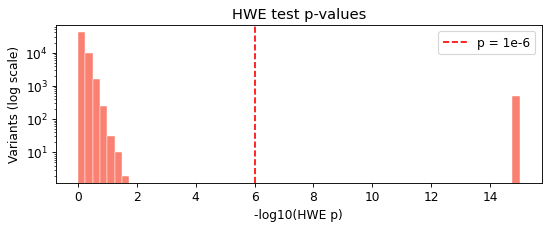

In [6]:
# ── Provided HWE test (heterozygote-deviation form) — run and use for QC ─────
def compute_hwe_midp(G):
    """
    Vectorised heterozygosity-based chi-squared test for HWE.
    Uses the heterozygote deviation formula: chi2 = n*(obs_het - exp_het)^2 / exp_het.
    Returns p-values for each variant (M,).
    """
    G_int  = np.where(np.isnan(G), -1, G).astype(int)
    n_samp = (G_int >= 0).sum(0).astype(float)
    n_AA   = (G_int == 0).sum(0).astype(float)
    n_AB   = (G_int == 1).sum(0).astype(float)
    # p_hat = REF allele freq; exp_het = 2*p*(1-p) is symmetric
    p_hat   = (2*n_AA + n_AB) / (2*n_samp + 1e-15)
    obs_het = n_AB / (n_samp + 1e-15)
    exp_het = 2 * p_hat * (1 - p_hat)
    chi2    = n_samp * (obs_het - exp_het)**2 / (exp_het + 1e-15)
    return stats.chi2.sf(chi2, df=1)

hwe_pvals = compute_hwe_midp(G_raw)
print(f"Variants failing HWE (p < 1e-6): {(hwe_pvals < 1e-6).sum():,}")

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(-np.log10(hwe_pvals + 1e-15), bins=60, color='salmon', edgecolor='white', linewidth=0.4)
ax.axvline(-np.log10(1e-6), color='red', linestyle='--', label='p = 1e-6')
ax.set_xlabel('-log10(HWE p)'); ax.set_ylabel('Variants (log scale)'); ax.set_yscale('log')
ax.set_title('HWE test p-values'); ax.legend()
plt.tight_layout(); plt.show()


In [7]:
# ── Apply QC filters ──────────────────────────────────────────────────────────
# Standard GWAS filters (thresholds given; no coding required here)
MISS_THRESH = 0.05     # remove variants with >5% missing
MAF_THRESH  = 0.01     # remove variants with MAF < 1%
HWE_THRESH  = 1e-6     # remove variants with HWE p < 1e-6

pass_miss = miss_rate < MISS_THRESH
pass_maf  = maf       > MAF_THRESH
pass_hwe  = hwe_pvals > HWE_THRESH   # provided HWE test from Exercise 1.3

qc_pass = pass_miss & pass_maf & pass_hwe

G_qc  = np.where(np.isnan(G_raw[:, qc_pass]), 0, G_raw[:, qc_pass])  # impute remaining NaN
pos_qc   = pos[qc_pass]
rsids_qc = rsids[qc_pass]
M_qc  = qc_pass.sum()

print("QC Summary")
print(f"  Pre-QC:               {M_raw:>7,} variants")
print(f"  After missingness QC: {pass_miss.sum():>7,} variants")
print(f"  After MAF QC:         {pass_maf.sum():>7,} variants")
print(f"  After HWE QC:         {pass_hwe.sum():>7,} variants")
print(f"  After all filters:    {M_qc:>7,} variants  ← G_qc")
# (G_raw is kept so the HWE chi-squared challenge can re-run on the raw genotypes.)


QC Summary
  Pre-QC:                52,500 variants
  After missingness QC:  52,200 variants
  After MAF QC:          49,590 variants
  After HWE QC:          52,000 variants
  After all filters:     48,790 variants  ← G_qc


## Part 2: Running GWAS — Continuous Trait

We'll use a vectorised OLS function (provided) that runs all M regressions efficiently.
The model for each variant $j$ is:

$$y_i = \mu + \beta_j \cdot G_{ij} + \gamma_1 \cdot \text{age}_i + \gamma_2 \cdot \text{sex}_i + \varepsilon_i$$

where $\hat{\beta}_j$ is the per-allele effect size on the standardised phenotype (in SD units).


In [8]:
def run_gwas(y, G, covars=None, chunk=5_000):
    """
    Vectorised OLS GWAS: regress phenotype y on each column of G.
    Processes variants in batches to keep peak memory usage low.

    Parameters
    ----------
    y      : (N,)    phenotype (will be mean-centred internally)
    G      : (N, M)  genotype matrix (0/1/2), NaN = missing (treated as mean)
    covars : (N, k)  covariate matrix (optional); age and sex recommended
    chunk  : int     variants per batch (default 5,000)

    Returns
    -------
    betas  : (M,)  per-variant OLS effect size estimate
    ses    : (M,)  standard error of beta
    pvals  : (M,)  two-sided p-value
    """
    N, M = G.shape
    if covars is None:
        C = np.ones((N, 1))
    else:
        C = np.column_stack([np.ones(N), covars])

    # Residualise y on covariates once (cheap)
    Q, _  = np.linalg.qr(C, mode='reduced')
    y_r   = y - Q @ (Q.T @ y)
    ss_y  = float(np.dot(y_r, y_r))
    n_df  = N - C.shape[1] - 1

    betas = np.empty(M); ses = np.empty(M)

    for s in range(0, M, chunk):
        e    = min(s + chunk, M)
        G_c  = G[:, s:e].astype(float)
        mu   = np.nanmean(G_c, axis=0)
        ri, ci = np.where(np.isnan(G_c)); G_c[ri, ci] = mu[ci]   # mean-impute
        G_r  = G_c - Q @ (Q.T @ G_c)                              # residualise
        ss_G = (G_r**2).sum(0)
        b    = G_r.T @ y_r / ss_G
        betas[s:e] = b
        rss  = ss_y - b**2 * ss_G
        ses[s:e]   = np.sqrt(np.clip(rss, 0, None) / n_df / ss_G)

    t_stats = betas / (ses + 1e-300)
    pvals   = 2 * stats.t.sf(np.abs(t_stats), df=n_df)
    return betas, ses, pvals

print('run_gwas() ready.')

run_gwas() ready.


In [9]:
betas_nocov, ses_nocov, pvals_nocov = run_gwas(y_cont, G_qc)


n_sig = (pvals_nocov < 5e-8).sum()
print(f"Genome-wide significant hits (p < 5e-8): {n_sig:,}")
print(f"Min p-value: {pvals_nocov.min():.2e}")


Genome-wide significant hits (p < 5e-8): 49
Min p-value: 1.21e-54


In [10]:
covars = np.column_stack([(age - age.mean()) / age.std(), sex])
betas_cov, ses_cov, pvals_cov = run_gwas(y_cont, G_qc, covars)

def lambda_gc(pvals):
    chi2_obs = stats.chi2.isf(np.clip(pvals, 1e-300, 1), df=1)
    return np.median(chi2_obs) / stats.chi2.median(df=1)

print(f"Lambda GC without covariates: {lambda_gc(pvals_nocov):.3f}")
print(f"Lambda GC with covariates:    {lambda_gc(pvals_cov):.3f}")


Lambda GC without covariates: 0.959
Lambda GC with covariates:    0.964


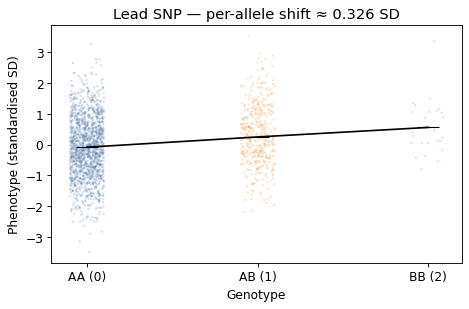

Expected BB−AA ≈ 2 × beta = 0.6514 SD
Observed BB−AA:              0.6441 SD


In [11]:
import seaborn as sns
j_top    = np.argmin(pvals_cov)
beta_top = betas_cov[j_top]
geno     = G_qc[:, j_top].astype(int)
means    = np.array([y_cont[geno == g].mean() for g in range(3)])
counts   = np.array([(geno == g).sum()        for g in range(3)])

_df = pd.DataFrame({'Genotype': geno, 'Phenotype': y_cont})
_df['Genotype'] = _df['Genotype'].map({0:'AA (0)', 1:'AB (1)', 2:'BB (2)'})
fig, ax = plt.subplots(figsize=(6, 4))
sns.stripplot(data=_df.sample(min(2000, len(_df)), random_state=0),
              x='Genotype', y='Phenotype', alpha=0.25, size=2, jitter=True,
              palette=['#4e79a7','#f28e2b','#e15759'], ax=ax)
ax.plot([0,1,2], means, color='black', linewidth=1.5, zorder=4)
ax.errorbar([0,1,2], means, fmt='_', color='black', markersize=20, linewidth=2, zorder=5)
ax.set_ylabel('Phenotype (standardised SD)')
ax.set_title(f'Lead SNP — per-allele shift ≈ {beta_top:.3f} SD')
plt.tight_layout(); plt.show()
print(f"Expected BB−AA ≈ 2 × beta = {2*beta_top:.4f} SD")
print(f"Observed BB−AA:              {means[2]-means[0]:.4f} SD")


## Part 3: GWAS — Binary Trait (Liability Threshold Model)

For binary (case/control) phenotypes, logistic regression is standard.
The model gives a **log-odds ratio** (log-OR) per allele.

The binary phenotype `y_bin` (1=case, 0=control) was derived from the continuous phenotype
via a **liability threshold**: individuals above the 90th percentile of liability are cases (~10% prevalence).
This is the standard liability threshold model for complex diseases.

We provide `run_logistic_gwas_fast()` — a score-test approximation that runs quickly.


In [12]:
def run_logistic_gwas_fast(y_bin, G, covars=None, chunk=5_000):
    """
    Fast logistic GWAS: score test (no iterative fitting per variant).
    Fits null model once; processes variants in batches to limit memory.

    Returns
    -------
    log_ors : (M,) approximate log-OR
    pvals   : (M,) score test p-values
    """
    from scipy.special import expit
    from scipy.optimize import minimize

    N, M = G.shape
    if covars is None:
        C0 = np.ones((N, 1))
    else:
        C0 = np.column_stack([np.ones(N), covars])
    k0 = C0.shape[1]

    def neg_ll(coef, X, y):
        mu = expit(X @ coef)
        return -np.sum(y * np.log(mu + 1e-15) + (1-y) * np.log(1 - mu + 1e-15))

    res0  = minimize(neg_ll, np.zeros(k0), args=(C0, y_bin), method='L-BFGS-B')
    mu0   = expit(C0 @ res0.x)
    resid = y_bin.astype(float) - mu0
    W0    = mu0 * (1 - mu0)

    # Precompute weighted projection: P_W = C0 @ (C0'WC0)^{-1} C0'W
    WC       = W0[:, None] * C0                              # (N, k0)
    CWWC_inv = np.linalg.inv(C0.T @ WC + 1e-12*np.eye(k0))  # (k0, k0)

    log_ors = np.empty(M); pvals = np.ones(M)

    for s in range(0, M, chunk):
        e    = min(s + chunk, M)
        G_c  = G[:, s:e].astype(float)
        mu   = np.nanmean(G_c, 0); ri, ci = np.where(np.isnan(G_c)); G_c[ri, ci] = mu[ci]
        G_rc = G_c - C0 @ (CWWC_inv @ (WC.T @ G_c))        # weighted residualise
        score  = G_rc.T @ resid
        var_sc = (G_rc**2 * W0[:, None]).sum(0)
        z      = score / np.sqrt(var_sc + 1e-15)
        pvals[s:e]   = 2 * stats.norm.sf(np.abs(z))
        log_ors[s:e] = score / (var_sc + 1e-15)

    return log_ors, pvals

print('run_logistic_gwas_fast() ready.')

run_logistic_gwas_fast() ready.


Genome-wide significant binary-trait hits: 39


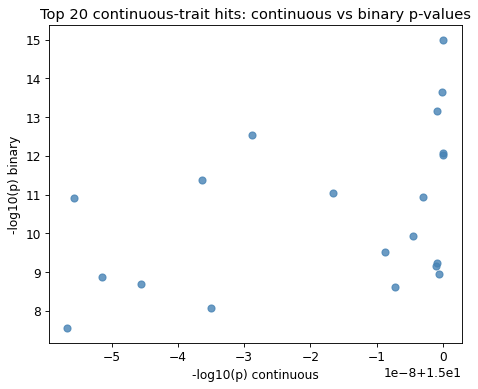

In [13]:
covars = np.column_stack([(age - age.mean()) / age.std(), sex])
log_ors, pvals_bin = run_logistic_gwas_fast(y_bin, G_qc, covars)

n_sig_bin = (pvals_bin < 5e-8).sum()
print(f"Genome-wide significant binary-trait hits: {n_sig_bin:,}")

top_ldl_idx = np.argsort(pvals_cov)[:20]
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(-np.log10(pvals_cov[top_ldl_idx]+1e-15),
           -np.log10(pvals_bin[top_ldl_idx]+1e-15),
           alpha=0.8, s=40, color='steelblue')
ax.set_xlabel('-log10(p) continuous'); ax.set_ylabel('-log10(p) binary')
ax.set_title('Top 20 continuous-trait hits: continuous vs binary p-values')
plt.tight_layout(); plt.show()


---

## Challenge Questions

These questions are for fast finishers and are not required in the 45-minute session.
They connect directly to ideas from the lecture.


### Challenge 1: HWE chi-squared test from scratch

For QC we used the provided heterozygosity-based test (`compute_hwe_midp`). The classic HWE test
is a **3-class chi-squared** comparing observed genotype counts (AA/AB/BB) to their HWE
expectations $n p^2, 2npq, nq^2$. Implement it yourself and compare your p-values to the provided
test — where do they agree, and where do they diverge?


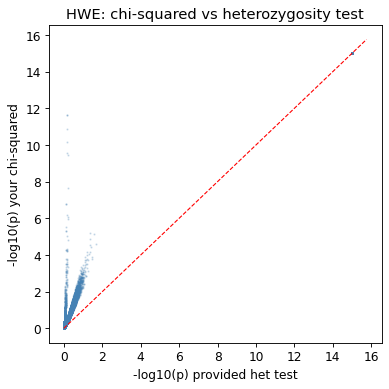

Fail HWE (chi-sq, p<1e-6):   511
Fail HWE (het test, p<1e-6): 500


In [14]:
def compute_hwe_chisq(G):
    G_int  = np.where(np.isnan(G), -1, G).astype(int)
    n_samp = (G_int >= 0).sum(0).astype(float)
    n_AA   = (G_int == 0).sum(0).astype(float)
    n_AB   = (G_int == 1).sum(0).astype(float)
    n_BB   = (G_int == 2).sum(0).astype(float)
    p      = (2*n_BB + n_AB) / (2*n_samp + 1e-15)
    exp_AA = n_samp * (1-p)**2
    exp_AB = n_samp * 2*p*(1-p)
    exp_BB = n_samp * p**2
    chi2   = ((n_AA-exp_AA)**2/(exp_AA+1e-8) +
              (n_AB-exp_AB)**2/(exp_AB+1e-8) +
              (n_BB-exp_BB)**2/(exp_BB+1e-8))
    return stats.chi2.sf(chi2, df=1)

hwe_chisq = compute_hwe_chisq(G_raw)
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(-np.log10(hwe_pvals + 1e-15), -np.log10(hwe_chisq + 1e-15),
           s=1, alpha=0.2, color='steelblue', rasterized=True)
lim = max((-np.log10(hwe_pvals + 1e-15)).max(), (-np.log10(hwe_chisq + 1e-15)).max()) * 1.05
ax.plot([0, lim], [0, lim], 'r--', linewidth=1)
ax.set_xlabel('-log10(p) provided het test'); ax.set_ylabel('-log10(p) your chi-squared')
ax.set_title('HWE: chi-squared vs heterozygosity test'); plt.tight_layout(); plt.show()
print(f"Fail HWE (chi-sq, p<1e-6):   {(hwe_chisq < 1e-6).sum():,}")
print(f"Fail HWE (het test, p<1e-6): {(hwe_pvals < 1e-6).sum():,}")


### Challenge 2: Additive, Dominant, and Recessive Models

The standard GWAS uses an **additive** model: genotype is encoded 0/1/2 (copies of ALT allele),
so the heterozygote AB is midway between AA and BB.

But what if the true effect is **dominant** (AB ≈ BB, one copy is enough) or
**recessive** (AB ≈ AA, two copies are needed)?

Recoding:
- **Dominant**: 0 → 0, 1 → 1, 2 → 1  (any ALT copy counts)
- **Recessive**: 0 → 0, 1 → 0, 2 → 1  (only homozygous ALT counts)

Two variants in this dataset have non-additive effects — one dominant, one recessive.
They may not be the genome-wide lead hit under the additive model!


Top dominant hit: rs1044720  p=1.88e-50
Top recessive hit: rs1001692  p=nan
True dominant locus was at col 294: p_additive=1.11e-13, p_dominant=1.96e-14
True recessive locus was at col 31072: p_additive=6.26e-06, p_recessive=2.08e-14


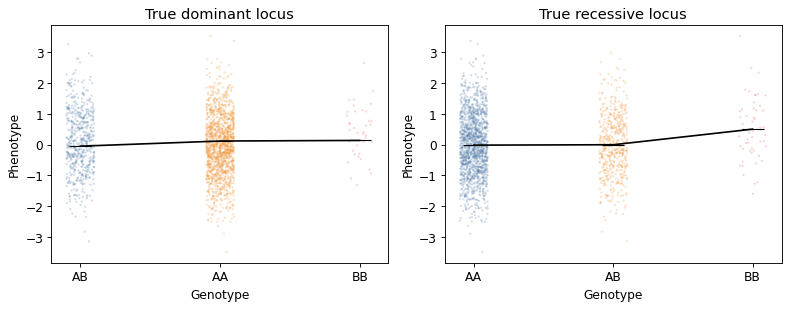

In [15]:
import seaborn as sns
G_dom = np.where(G_qc >= 1, 1, 0).astype(float)
G_rec = np.where(G_qc == 2, 1, 0).astype(float)

covars = np.column_stack([(age - age.mean()) / age.std(), sex])
betas_dom, _, pvals_dom = run_gwas(y_cont, G_dom, covars)
betas_rec, _, pvals_rec = run_gwas(y_cont, G_rec, covars)

j_dom = np.argmin(pvals_dom); j_rec = np.argmin(pvals_rec)
print(f"Top dominant hit: {rsids_qc[j_dom]}  p={pvals_dom[j_dom]:.2e}")
print(f"Top recessive hit: {rsids_qc[j_rec]}  p={pvals_rec[j_rec]:.2e}")
# True injected loci: dom_idx_qc, rec_idx_qc
print(f"True dominant locus was at col {dom_idx_qc}: p_additive={pvals_cov[dom_idx_qc]:.2e}, p_dominant={pvals_dom[dom_idx_qc]:.2e}")
print(f"True recessive locus was at col {rec_idx_qc}: p_additive={pvals_cov[rec_idx_qc]:.2e}, p_recessive={pvals_rec[rec_idx_qc]:.2e}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, j, title in zip(axes, [dom_idx_qc, rec_idx_qc], ['True dominant locus', 'True recessive locus']):
    geno = G_qc[:, j].astype(int)
    _df  = pd.DataFrame({'Genotype': geno, 'Phenotype': y_cont})
    _df['Genotype'] = _df['Genotype'].map({0:'AA', 1:'AB', 2:'BB'})
    sns.stripplot(data=_df.sample(min(2000, len(_df)), random_state=0),
                  x='Genotype', y='Phenotype', alpha=0.25, size=2, jitter=True,
                  palette=['#4e79a7','#f28e2b','#e15759'], ax=ax)
    means = [y_cont[geno==g].mean() for g in range(3)]
    ax.plot([0,1,2], means, color='black', linewidth=1.5, zorder=4)
    ax.errorbar([0,1,2], means, fmt='_', color='black', markersize=20, linewidth=2, zorder=5)
    ax.set_title(title); ax.set_ylabel('Phenotype')
plt.tight_layout(); plt.show()


### Challenge 3: Manual LocusZoom plot

A **LocusZoom plot** shows $-\log_{10}(p)$ vs. position for a region around a hit, with points
**coloured by LD** ($r^2$) with the lead variant. It reveals the LD structure that produces the
"tower" you'll see in a Manhattan plot (Session 2) — neighbouring variants are associated only
because they are correlated with the causal one.

We use the covariate-adjusted continuous-trait GWAS (`pvals_cov`) and the genotypes `G_qc`.


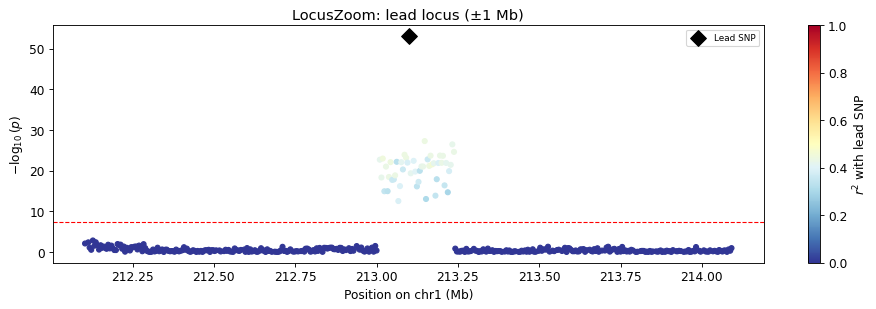

In [16]:
j_lead = np.argmin(pvals_cov); pos_lead = pos_qc[j_lead]
region_mask = np.abs(pos_qc - pos_lead) < 1000
g_lead = G_qc[:, j_lead]
G_region = G_qc[:, region_mask]
r2 = np.array([np.corrcoef(g_lead, G_region[:, k])[0,1]**2 for k in range(G_region.shape[1])])

cmap = plt.cm.RdYlBu_r; norm = mcolors.Normalize(vmin=0, vmax=1)
fig, ax = plt.subplots(figsize=(12, 4))
sc = ax.scatter(pos_qc[region_mask]/1000, -np.log10(pvals_cov[region_mask]+1e-300),
                c=r2, cmap=cmap, norm=norm, s=20, zorder=3)
ax.scatter([pos_lead/1000], [-np.log10(pvals_cov[j_lead]+1e-300)],
           s=100, marker='D', color='black', zorder=5, label='Lead SNP')
plt.colorbar(sc, ax=ax, label=r'$r^2$ with lead SNP')
ax.axhline(-np.log10(5e-8), color='red', linestyle='--', linewidth=1)
ax.set_xlabel('Position on chr1 (Mb)'); ax.set_ylabel(r'$-\log_{10}(p)$')
ax.set_title('LocusZoom: lead locus (±1 Mb)'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


### Challenge 4: Drosophila Linkage Analysis (Hard!)

*(Inspired by Sturtevant, 1913 — the first genetic map.)*

We have 2,000 fly offspring from a test cross:
- **Mother**: heterozygous for 6 X-linked traits (carrier) + 2 autosomal traits
- **Father**: hemizygous wild-type

The dataset `fly_df` has columns: `sex` (1=male, 0=female) and 8 trait columns.
You are told there are 6 X-linked traits and 2 autosomal traits — but the column names
don't tell you which is which.

**Your tasks**:
1. Identify which traits are X-linked (hint: look at trait frequency in males vs females).
2. For the X-linked traits, compute pairwise recombination frequencies.
3. Use the recombination frequencies to infer the order and spacing of the 6 genes on the chromosome.


In [17]:
trait_cols = [c for c in fly_df.columns if c.startswith('trait_')]
freq_by_sex = fly_df.groupby('sex')[trait_cols].mean()
print(freq_by_sex.T)
# X-linked traits have freq ~0.5 in males and ~0 in females
x_linked_traits = freq_by_sex.columns[(freq_by_sex.loc[1] > 0.3) & (freq_by_sex.loc[0] < 0.1)].tolist()
print(f"\nX-linked traits: {x_linked_traits}")


sex               0      1
trait_eye     0.000  0.481
trait_thorax  0.330  0.347
trait_wing    0.000  0.488
trait_leg     0.000  0.493
trait_notch   0.000  0.480
trait_vein    0.000  0.473
trait_scute   0.000  0.487
trait_band    0.492  0.507

X-linked traits: ['trait_eye', 'trait_wing', 'trait_leg', 'trait_notch', 'trait_vein', 'trait_scute']


In [18]:
males = fly_df[fly_df['sex'] == 1]
n_x = len(x_linked_traits)
recomb_freq = np.zeros((n_x, n_x))
for i, ti in enumerate(x_linked_traits):
    for j, tj in enumerate(x_linked_traits):
        recomb_freq[i, j] = (males[ti] != males[tj]).mean()
print("Pairwise recombination frequencies:")
print(pd.DataFrame(recomb_freq, index=x_linked_traits, columns=x_linked_traits).round(3))


Pairwise recombination frequencies:
             trait_eye  trait_wing  trait_leg  trait_notch  trait_vein  \
trait_eye        0.000       0.051      0.154        0.263       0.282   
trait_wing       0.051       0.000      0.107        0.228       0.253   
trait_leg        0.154       0.107      0.000        0.153       0.198   
trait_notch      0.263       0.228      0.153        0.000       0.057   
trait_vein       0.282       0.253      0.198        0.057       0.000   
trait_scute      0.334       0.305      0.262        0.159       0.114   

             trait_scute  
trait_eye          0.334  
trait_wing         0.305  
trait_leg          0.262  
trait_notch        0.159  
trait_vein         0.114  
trait_scute        0.000  


In [19]:
def haldane_d(r):
    return -50 * np.log(1 - 2*np.clip(r, 0, 0.499))

rf_df = pd.DataFrame(recomb_freq, index=x_linked_traits, columns=x_linked_traits)
# Find closest pair
np.fill_diagonal(recomb_freq, 1.0)
i_min, j_min = np.unravel_index(recomb_freq.argmin(), recomb_freq.shape)
print(f"Closest pair: {x_linked_traits[i_min]} — {x_linked_traits[j_min]}: "
      f"r={recomb_freq[i_min,j_min]:.3f}, d={haldane_d(recomb_freq[i_min,j_min]):.1f} cM")


Closest pair: trait_eye — trait_wing: r=0.051, d=5.4 cM


### Challenge 5: Ascertainment by age of onset (Medium)

Disease cohorts are often **ascertained** — individuals only enter as *cases* once they have
been diagnosed. For a late-onset disease, someone who will eventually develop it but is still
young looks like a *control* at recruitment.

Model this: treat the binary trait as a late-onset disease and **recode every case younger than
60 as a control**, then re-run the logistic GWAS. Compare the hits to the fully-ascertained
baseline. What happens to power, and why?


Cases: 1000 -> 472 after requiring onset age >= 60
Genome-wide-sig hits:  baseline 39, ascertained 5


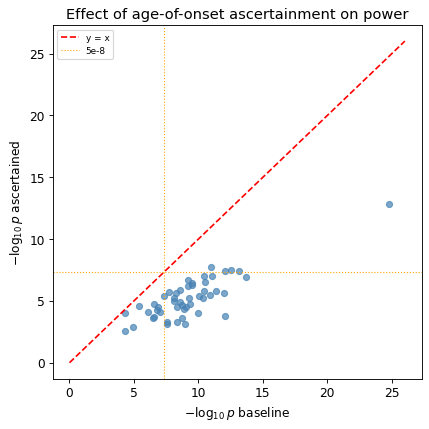

In [20]:
covars = np.column_stack([(age - age.mean()) / age.std(), sex])
_, pvals_base = run_logistic_gwas_fast(y_bin, G_qc, covars)

y_asc = y_bin.copy()
y_asc[(y_bin == 1) & (age < 60)] = 0
print(f"Cases: {int(y_bin.sum())} -> {int(y_asc.sum())} after requiring onset age >= 60")
_, pvals_asc = run_logistic_gwas_fast(y_asc, G_qc, covars)
print(f"Genome-wide-sig hits:  baseline {int((pvals_base<5e-8).sum())}, "
      f"ascertained {int((pvals_asc<5e-8).sum())}")

sugg = np.where(pvals_base < 1e-4)[0]
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(-np.log10(pvals_base[sugg]+1e-300), -np.log10(pvals_asc[sugg]+1e-300),
           s=30, alpha=0.7, color='steelblue')
lim = -np.log10(min(pvals_base[sugg].min(), pvals_asc[sugg].min()) + 1e-300) * 1.05
ax.plot([0, lim], [0, lim], 'r--', label='y = x')
ax.axhline(-np.log10(5e-8), color='orange', ls=':', lw=1)
ax.axvline(-np.log10(5e-8), color='orange', ls=':', lw=1, label='5e-8')
ax.set_xlabel(r'$-\log_{10}p$ baseline'); ax.set_ylabel(r'$-\log_{10}p$ ascertained')
ax.set_title('Effect of age-of-onset ascertainment on power'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
# Dropping young cases ~halves the case count → less power → points fall below y=x.


### Challenge 6: Polygenic scores — predicting the genetic component (Hard)

A **polygenic score** is the predicted genetic value $\hat g_i = \sum_j x_{ij}\,\hat\beta_j$,
built from GWAS effect estimates. To judge prediction honestly we fit the effects in a
**training** half and score an independent **test** half.

Build a PGS for the continuous trait two ways — using **all** variants vs only the
**genome-wide-significant** ones — and correlate each with the true phenotype in the test set.
Then do the same for the binary trait and show the PGS split by case/control.

How would you push the correlation higher still? (LD clumping, p-value thresholding, penalized
or Bayesian shrinkage of the effects.)


  corr(PGS [all variants], y_cont) on test set = 0.022
  corr(PGS [genome-wide-sig only], y_cont) on test set = 0.113


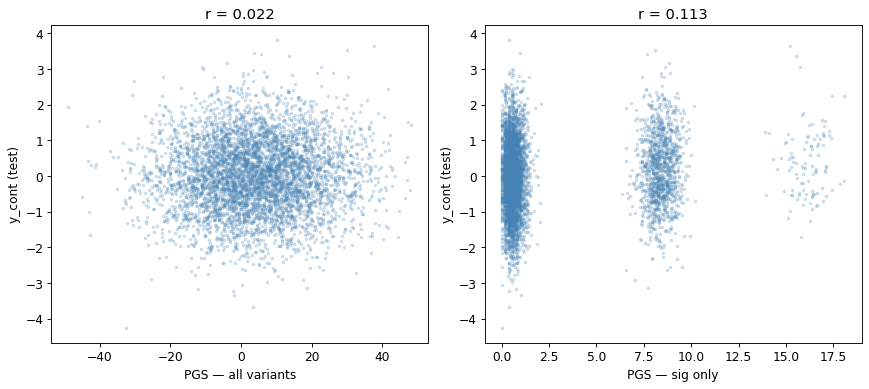

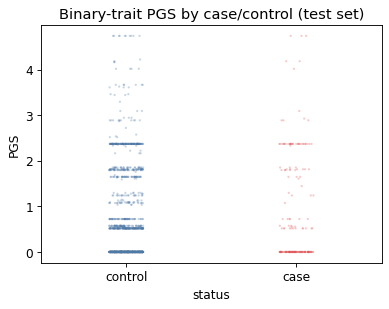

In [21]:
import seaborn as sns
rng = np.random.default_rng(7)
perm = rng.permutation(N); tr, te = perm[:N//2], perm[N//2:]
cov_tr = np.column_stack([(age[tr]-age.mean())/age.std(), sex[tr]])

b_tr, _, p_tr = run_gwas(y_cont[tr], G_qc[tr], cov_tr)
pgs_all = G_qc[te] @ b_tr
sig = p_tr < 5e-8
pgs_sig = G_qc[te][:, sig] @ b_tr[sig]
for nm, pgs in [('all variants', pgs_all), ('genome-wide-sig only', pgs_sig)]:
    print(f"  corr(PGS [{nm}], y_cont) on test set = {np.corrcoef(pgs, y_cont[te])[0,1]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, (nm, pgs) in zip(axes, [('all variants', pgs_all), ('sig only', pgs_sig)]):
    ax.scatter(pgs, y_cont[te], s=5, alpha=0.2, color='steelblue')
    ax.set_xlabel(f'PGS — {nm}'); ax.set_ylabel('y_cont (test)')
    ax.set_title(f'r = {np.corrcoef(pgs, y_cont[te])[0,1]:.3f}')
plt.tight_layout(); plt.show()

log_or_tr, pbin_tr = run_logistic_gwas_fast(y_bin[tr], G_qc[tr], cov_tr)
sb = pbin_tr < 5e-8
pgs_bin = G_qc[te][:, sb] @ log_or_tr[sb] if sb.sum() else G_qc[te] @ log_or_tr
dfb = pd.DataFrame({'status': np.where(y_bin[te]==1, 'case', 'control'), 'PGS': pgs_bin})
fig, ax = plt.subplots(figsize=(5, 4))
sns.stripplot(data=dfb.sample(min(2000, len(dfb)), random_state=0),
              x='status', y='PGS', alpha=0.3, size=2,
              palette=['#4e79a7', '#e15759'], ax=ax)
ax.set_title('Binary-trait PGS by case/control (test set)'); plt.tight_layout(); plt.show()
# All-variant PGS is mostly noise out-of-sample; restricting to sig variants raises the correlation.
